# Credit Card Approval Analysis — End-to-End

**Dataset:** `CreditCard.csv` (1,319 applications, 12 features + target `card`)
**Goal:** understand what drives credit card approval and build an interpretable, well-validated classifier.

### Notebook roadmap
1. Setup & data load
2. Data quality audit & cleaning
3. Exploratory data analysis (univariate, target relationships, correlations)
4. **Leakage audit** — a critical step for this dataset
5. Feature engineering & preprocessing pipeline
6. Model benchmarking (6 candidate models, stratified CV)
7. Hyperparameter tuning of the winner
8. Test-set evaluation: ROC/PR curves, confusion matrix, threshold choice
9. Interpretability: coefficients, permutation importance
10. Model selection recommendations & next steps


## 1. Setup & data load

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

pd.set_option("display.width", 140); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "figure.autolayout": True})
RANDOM_STATE = 42

CSV = "data/CreditCard.csv"
df = pd.read_csv(CSV).drop(columns=["rownames"])
print(df.shape)
df.head()

(1319, 12)


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


### Data dictionary

| Column | Meaning |
|---|---|
| `card` | **Target** — application accepted (yes/no) |
| `reports` | Number of major derogatory reports |
| `age` | Age in years (fractional) |
| `income` | Yearly income, USD 10,000s |
| `share` | Monthly credit card expenditure / yearly income |
| `expenditure` | Average monthly credit card expenditure |
| `owner` | Owns a home |
| `selfemp` | Self-employed |
| `dependents` | Number of dependents |
| `months` | Months living at current address |
| `majorcards` | Number of major credit cards held |
| `active` | Number of active credit accounts |


## 2. Data quality audit

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(),
})
display(audit)
print("Duplicate rows:", df.duplicated().sum())
df.describe().T

,dtype,n_missing,n_unique
card,str,0,2
reports,int64,0,13
age,float64,0,418
income,float64,0,431
share,float64,0,1162
expenditure,float64,0,981
owner,str,0,2
selfemp,str,0,2
dependents,int64,0,7
months,int64,0,193


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
reports,1319.0,0.456406,1.345267,0.000000,0.000000,0.000000,0.000000,14.00000
age,1319.0,33.213103,10.142783,0.166667,25.416670,31.250000,39.416670,83.50000
income,1319.0,3.365376,1.693902,0.210000,2.243750,2.900000,4.000000,13.50000
share,1319.0,0.068732,0.094656,0.000109,0.002316,0.038827,0.093617,0.90632
expenditure,1319.0,185.057071,272.218917,0.000000,4.583333,101.298300,249.035800,3099.50500
dependents,1319.0,0.993935,1.247745,0.000000,0.000000,1.000000,2.000000,6.00000
months,1319.0,55.267627,66.271746,0.000000,12.000000,30.000000,72.000000,540.00000
majorcards,1319.0,0.817286,0.386579,0.000000,1.000000,1.000000,1.000000,1.00000
active,1319.0,6.996967,6.305812,0.000000,2.000000,6.000000,11.000000,46.00000


In [3]:
# Sanity checks on implausible values
print("age < 18:", (df.age < 18).sum())
print(df.loc[df.age < 18, ["age","income","months","card"]].head())

# Treat sub-adult ages as data-entry errors -> NaN, imputed later in the pipeline
df["age"] = df["age"].where(df["age"] >= 18, np.nan)
print("age NaNs after fix:", df.age.isna().sum())

age < 18: 7
          age  income  months card
78   0.500000    3.05      94  yes
323  0.166667    3.24      25  yes
434  0.583333    2.50     150  yes
461  0.750000    3.00      18   no
655  0.583333    4.00      24  yes
age NaNs after fix: 7


In [4]:
TARGET = "card"
y = (df[TARGET] == "yes").astype(int)
print(y.value_counts(), "\napproval rate: %.1f%%" % (100*y.mean()))

card
1    1023
0     296
Name: count, dtype: int64 
approval rate: 77.6%


## 3. Exploratory data analysis

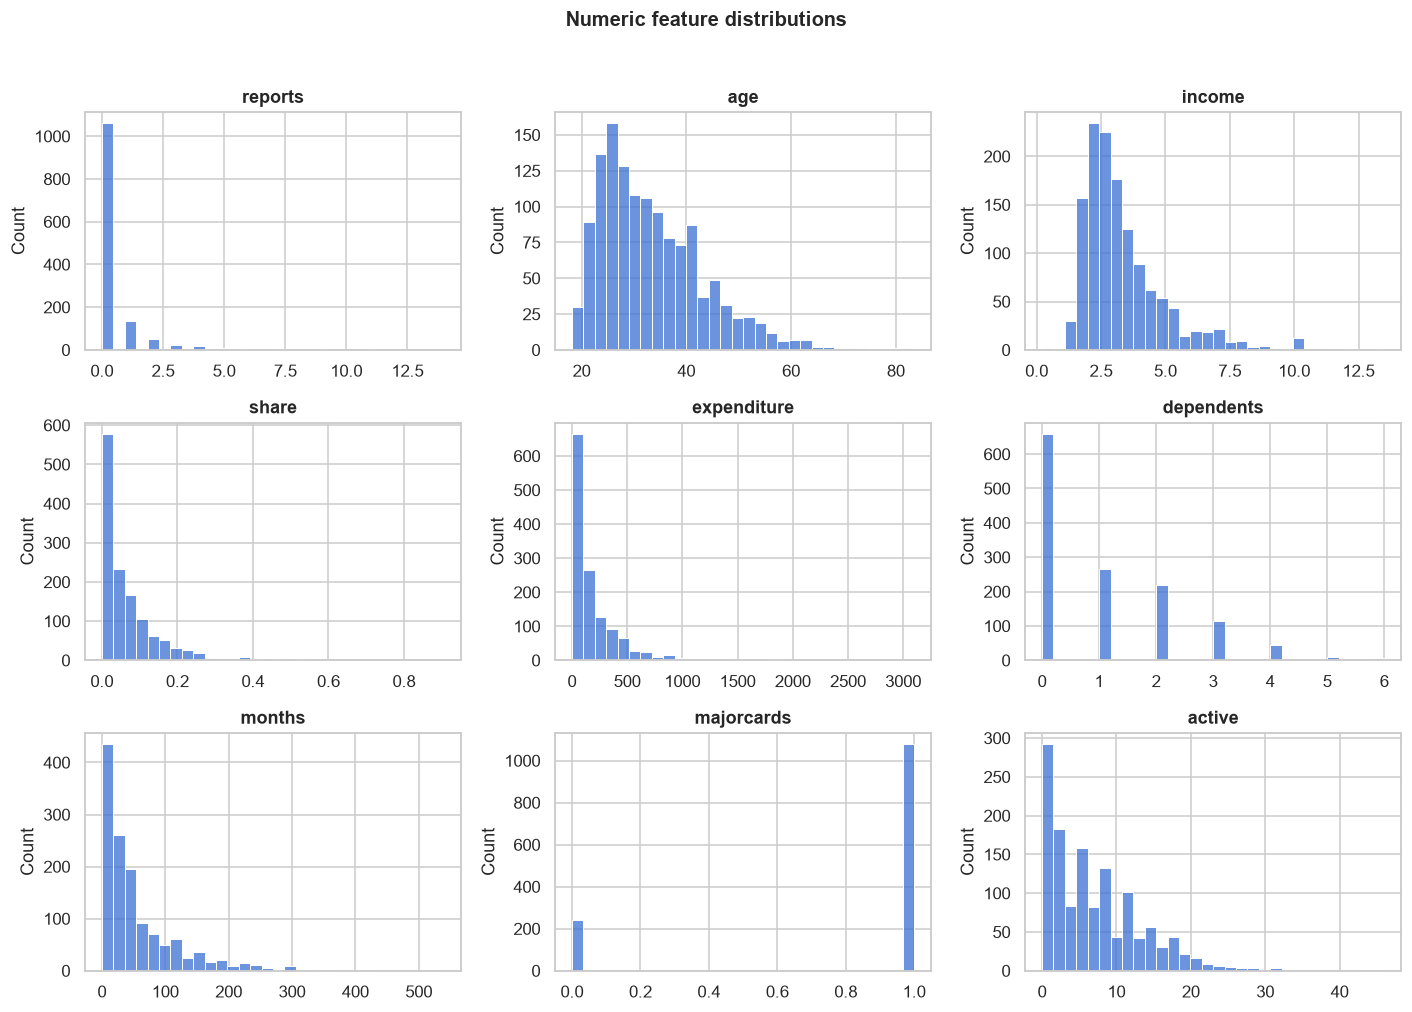

In [5]:
num_cols = ["reports","age","income","share","expenditure","dependents","months","majorcards","active"]
cat_cols = ["owner","selfemp"]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#3b6fd4")
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Numeric feature distributions", y=1.02, fontsize=13, fontweight="bold")
plt.show()

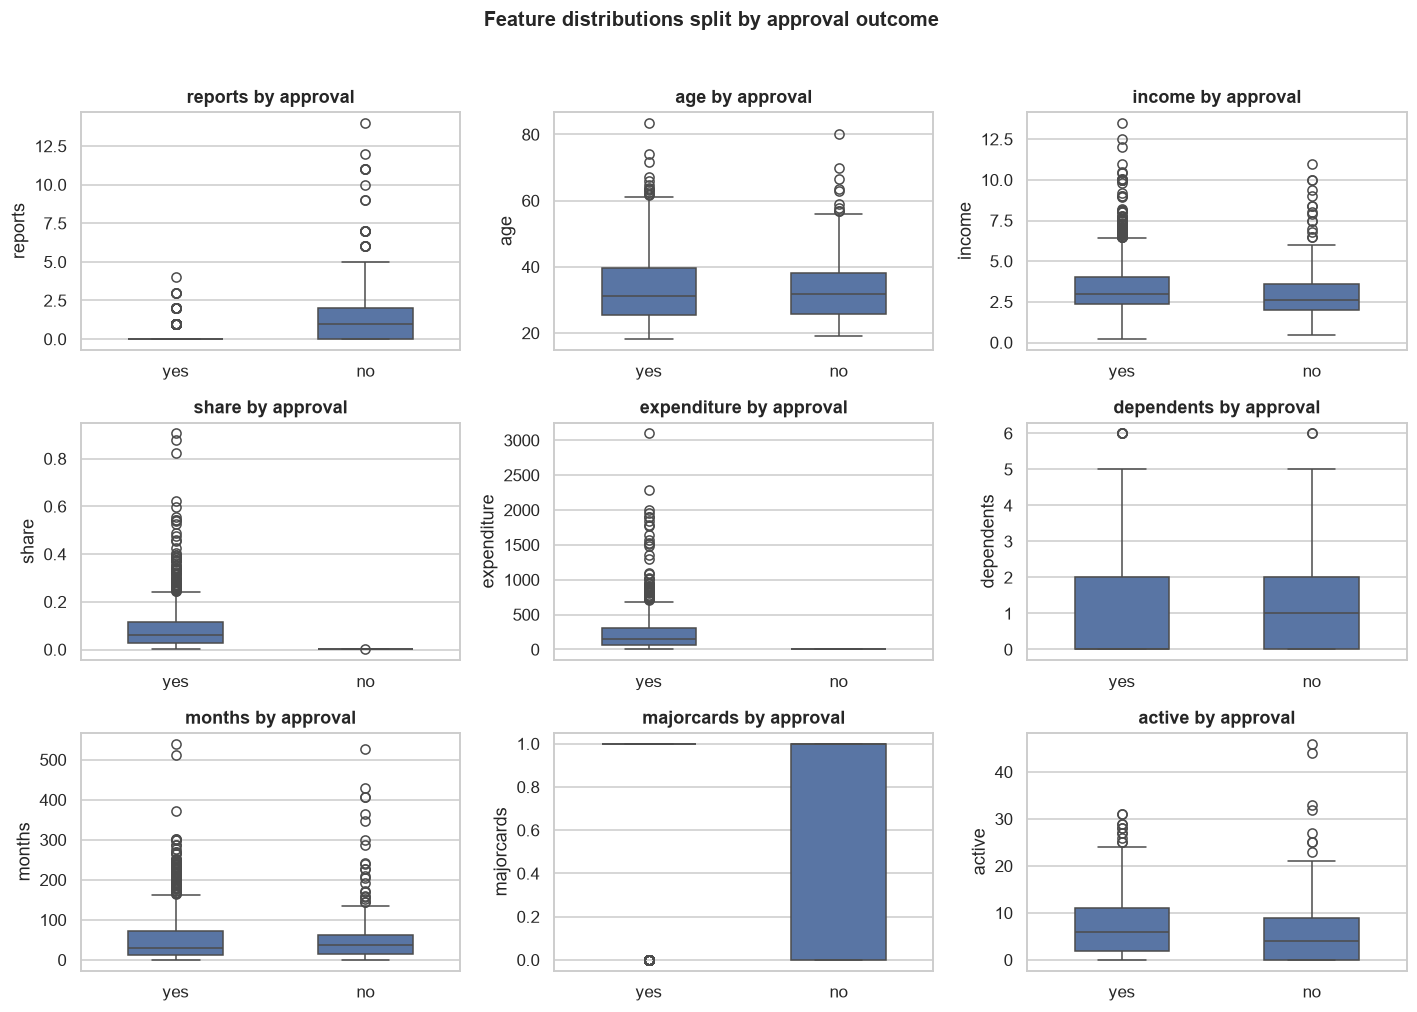

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df.assign(card=df[TARGET]), x="card", y=col, ax=ax, width=.5)
    ax.set_title(f"{col} by approval"); ax.set_xlabel("")
fig.suptitle("Feature distributions split by approval outcome", y=1.02, fontsize=13, fontweight="bold")
plt.show()

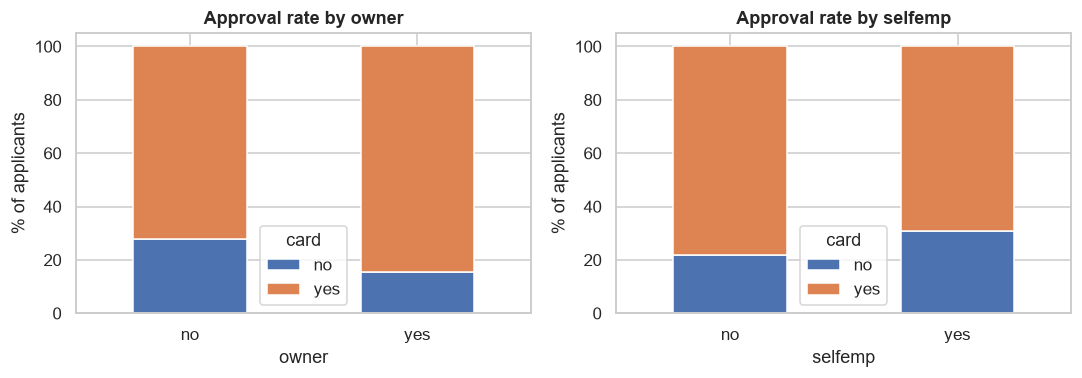

--- approval rate by owner ---
owner
no     0.721
yes    0.845 

--- approval rate by selfemp ---
selfemp
no     0.782
yes    0.692 

--- approval rate by reports ---
reports
0     0.863
1     0.657
2     0.260
3     0.167
4     0.059
5     0.000
6     0.000
7     0.000
9     0.000
10    0.000
11    0.000
12    0.000
14    0.000 

--- approval rate by majorcards ---
majorcards
0    0.680
1    0.797 

--- approval rate by dependents ---
dependents
0    0.789
1    0.798
2    0.711
3    0.765
4    0.795
5    0.778
6    0.714 



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, col in zip(axes, cat_cols):
    (pd.crosstab(df[col], df[TARGET], normalize="index")*100).plot(kind="bar", stacked=True, ax=ax, rot=0)
    ax.set_title(f"Approval rate by {col}"); ax.set_ylabel("% of applicants"); ax.legend(title="card")
plt.show()

for col in cat_cols + ["reports","majorcards","dependents"]:
    print(f"--- approval rate by {col} ---")
    print((df.groupby(col)[TARGET].apply(lambda s: (s=="yes").mean()).round(3)).to_string(), "\n")

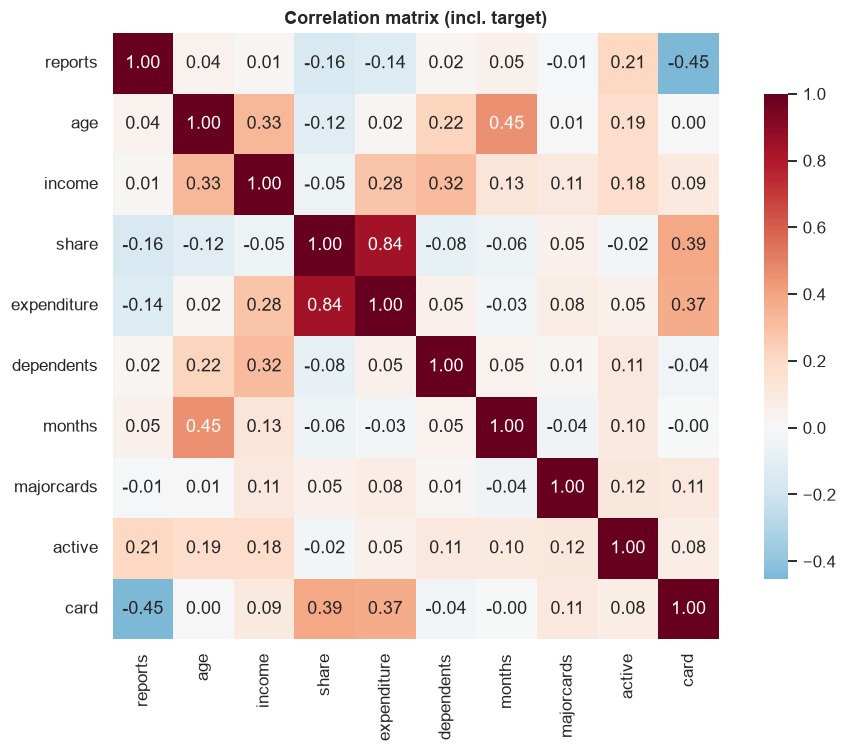

In [8]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].assign(card=y).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink":.8})
plt.title("Correlation matrix (incl. target)")
plt.show()

### EDA takeaways
- **Approval is heavily imbalanced toward "yes"** (~78%), so accuracy alone is a weak metric — use ROC-AUC / PR-AUC / recall on the *denied* class.
- `reports` (derogatory reports) is the strongest *legitimate* negative signal: approval collapses as reports rise.
- `share` and `expenditure` correlate almost perfectly with the target — investigated next.
- `income`, `owner`, `active`, `majorcards` carry mild positive signal; `age`, `months`, `selfemp` are weak.


## 4. Leakage audit — the single most important step

`expenditure` is *average monthly credit card spending* and `share` is that spending divided by income.
An applicant who was **denied a card cannot spend on it**, so these variables are measured *after* the
decision. Confirming this makes the difference between an honest model and a fake 99% AUC.

In [9]:
print("Zero expenditure by outcome:")
print(df.groupby(TARGET)["expenditure"].agg(n="size", pct_zero=lambda s: (s==0).mean().round(3), mean="mean"))
print()
print("If expenditure > 0 -> approved rate: %.4f" % y[df.expenditure > 0].mean())
print("If expenditure == 0 -> approved rate: %.4f" % y[df.expenditure == 0].mean())

Zero expenditure by outcome:
         n  pct_zero        mean
card                            
no     296     1.000    0.000000
yes   1023     0.021  238.602421

If expenditure > 0 -> approved rate: 1.0000
If expenditure == 0 -> approved rate: 0.0662


**Verdict:** every denied applicant has exactly `expenditure == 0`, and virtually every applicant with
non-zero expenditure was approved. `share` and `expenditure` are **target leakage** and are dropped from
all modeling below. We keep them only as an illustration of the trap.

In [10]:
LEAKY = ["share", "expenditure"]
FEATURES = [c for c in df.columns if c not in LEAKY + [TARGET]]
X = df[FEATURES].copy()
print("Modeling features:", FEATURES)

Modeling features: ['reports', 'age', 'income', 'owner', 'selfemp', 'dependents', 'months', 'majorcards', 'active']


## 5. Feature engineering & preprocessing pipeline

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def engineer(d):
    d = d.copy()
    d["income_per_dependent"] = d["income"] / (d["dependents"] + 1)
    d["has_derogatory"]       = (d["reports"] > 0).astype(int)
    d["cards_per_active"]     = d["majorcards"] / (d["active"] + 1)
    d["years_at_address"]     = d["months"] / 12
    d["log_income"]           = np.log1p(d["income"])
    return d

X_fe = engineer(X)
NUM = [c for c in X_fe.columns if c not in cat_cols]
CAT = cat_cols

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUM),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))]), CAT),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, "train approval %.3f / test approval %.3f" % (y_train.mean(), y_test.mean()))

(1055, 14) (264, 14) train approval 0.775 / test approval 0.777


## 6. Model benchmarking

Six candidates spanning the interpretability–flexibility spectrum, all inside the same preprocessing
pipeline and scored with 5-fold **stratified** CV. `class_weight="balanced"` / `scale_pos_weight`
counteracts the class imbalance.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

neg_pos = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=400, min_samples_leaf=3, 
                                                  class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, subsample=0.9,
                                         colsample_bytree=0.9, scale_pos_weight=neg_pos, eval_metric="logloss",
                                         random_state=RANDOM_STATE, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "average_precision", "f1", "recall", "precision", "balanced_accuracy"]

rows = []
for name, est in models.items():
    pipe = Pipeline([("pre", pre), ("clf", est)])
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"model": name, **{m: r[f"test_{m}"].mean() for m in scoring},
                 "roc_auc_sd": r["test_roc_auc"].std()})

bench = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).round(4).reset_index(drop=True)
bench

,model,roc_auc,average_precision,f1,recall,precision,balanced_accuracy,roc_auc_sd
0,Logistic Regression,0.8528,0.9282,0.8559,0.8069,0.9124,0.7683,0.0313
1,Random Forest,0.8390,0.9305,0.9054,0.9291,0.8830,0.7514,0.0194
2,Gradient Boosting,0.8365,0.9223,0.9148,0.9584,0.8751,0.7430,0.0239
3,XGBoost,0.8282,0.9231,0.8717,0.8557,0.8885,0.7421,0.0238
4,K-Nearest Neighbors,0.8222,0.9187,0.8992,0.9535,0.8512,0.6879,0.0302
5,Decision Tree,0.7848,0.8997,0.8445,0.8205,0.8774,0.7082,0.0385


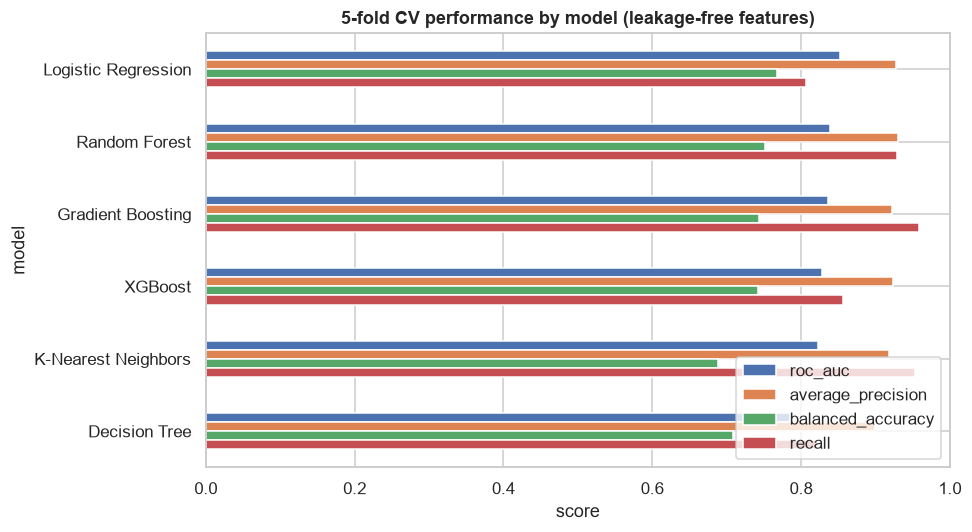

ROC-AUC WITH leakage (do not trust): 0.9883
Best honest ROC-AUC:               0.8528


In [13]:
ax = bench.set_index("model")[["roc_auc","average_precision","balanced_accuracy","recall"]].plot(
    kind="barh", figsize=(9,5))
ax.set_title("5-fold CV performance by model (leakage-free features)")
ax.set_xlabel("score"); ax.set_xlim(0,1); ax.invert_yaxis()
plt.show()

# Reference: how good it *looks* if we illegally keep the leaky features
leak_pipe = Pipeline([("pre", ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                                  ("sc", StandardScaler())]), NUM+LEAKY),
                                                 ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                                                                   ("oh", OneHotEncoder(drop="if_binary"))]), CAT)])),
                      ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
Xl = engineer(df[FEATURES]).join(df[LEAKY])
leak_auc = cross_validate(leak_pipe, Xl.loc[X_train.index], y_train, cv=cv, scoring="roc_auc")["test_score"].mean()
print("ROC-AUC WITH leakage (do not trust): %.4f" % leak_auc)
print("Best honest ROC-AUC:               %.4f" % bench.roc_auc.max())

## 7. Hyperparameter tuning

In [14]:
best_name = bench.loc[0, "model"]
print("Tuning:", best_name)

grids = {
 "Logistic Regression": ({"clf__C":[0.01,0.1,0.5,1,5,10], "clf__penalty":["l1","l2"], "clf__solver":["liblinear"]},
                          LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
 "Random Forest": ({"clf__n_estimators":[300,600], "clf__max_depth":[None,6,10], "clf__min_samples_leaf":[1,3,5]},
                    RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
 "Gradient Boosting": ({"clf__n_estimators":[200,400], "clf__learning_rate":[0.03,0.1], "clf__max_depth":[2,3]},
                    GradientBoostingClassifier(random_state=RANDOM_STATE)),
 "XGBoost": ({"clf__n_estimators":[300,600], "clf__learning_rate":[0.03,0.1], "clf__max_depth":[2,3,4],
              "clf__subsample":[0.8,1.0]},
              XGBClassifier(scale_pos_weight=neg_pos, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
 "Decision Tree": ({"clf__max_depth":[3,4,5,6], "clf__min_samples_leaf":[1,5,10]},
                    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
 "K-Nearest Neighbors": ({"clf__n_neighbors":[5,11,15,25], "clf__weights":["uniform","distance"]},
                    KNeighborsClassifier()),
}
grid, base = grids[best_name]
gs = GridSearchCV(Pipeline([("pre", pre), ("clf", base)]), grid, cv=cv, scoring="roc_auc", n_jobs=-1)
gs.fit(X_train, y_train)
print("best params:", gs.best_params_)
print("best CV ROC-AUC: %.4f" % gs.best_score_)
final = gs.best_estimator_

Tuning: Logistic Regression
best params: {'clf__C': 5, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
best CV ROC-AUC: 0.8535


## 8. Test-set evaluation

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay, f1_score)

proba = final.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("Test ROC-AUC : %.4f" % roc_auc_score(y_test, proba))
print("Test PR-AUC  : %.4f" % average_precision_score(y_test, proba))
print()
print(classification_report(y_test, pred, target_names=["denied","approved"], digits=3))

Test ROC-AUC : 0.8231
Test PR-AUC  : 0.9387

              precision    recall  f1-score   support

      denied      0.475     0.644     0.547        59
    approved      0.886     0.795     0.838       205

    accuracy                          0.761       264
   macro avg      0.680     0.720     0.692       264
weighted avg      0.794     0.761     0.773       264



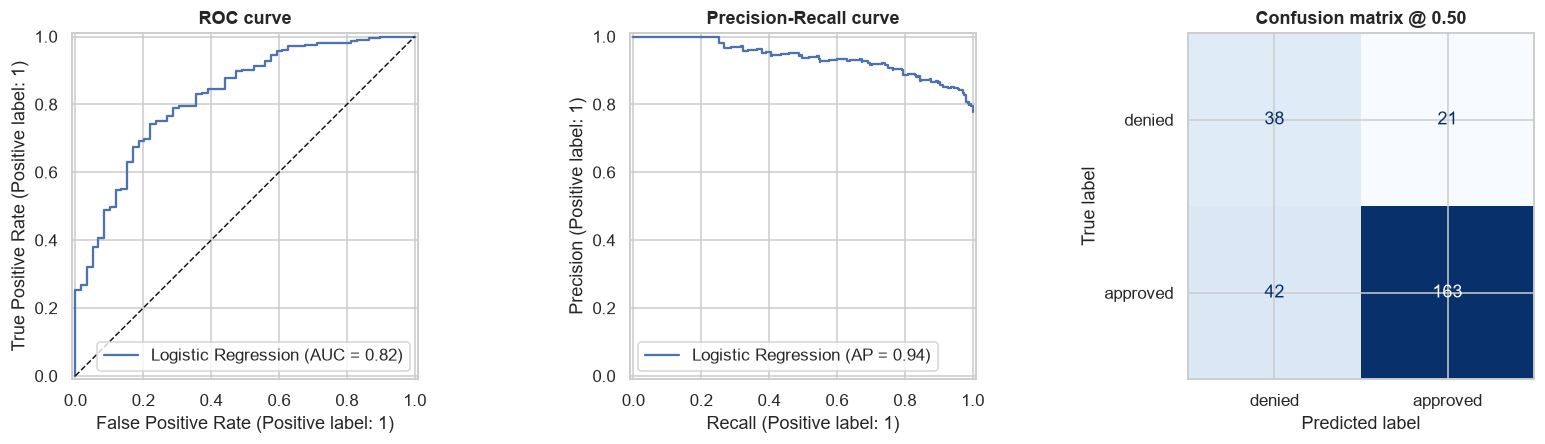

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0], name=best_name)
axes[0].plot([0,1],[0,1],"k--",lw=1); axes[0].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1], name=best_name)
axes[1].set_title("Precision-Recall curve")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["denied","approved"]).plot(ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("Confusion matrix @ 0.50")
plt.show()

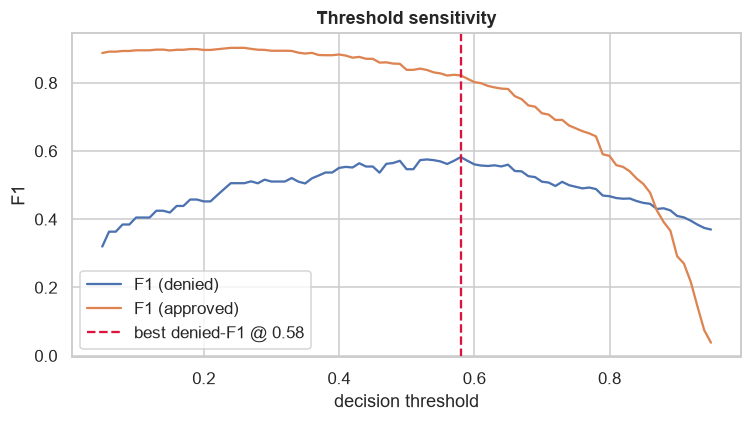

              precision    recall  f1-score   support

      denied      0.465     0.780     0.582        59
    approved      0.921     0.741     0.822       205

    accuracy                          0.750       264
   macro avg      0.693     0.761     0.702       264
weighted avg      0.819     0.750     0.768       264



In [17]:
# Threshold tuning: which cutoff maximises F1 on the minority (denied) class?
ths = np.linspace(0.05, 0.95, 91)
res = pd.DataFrame({"threshold": ths})
res["f1_denied"] = [f1_score(1-y_test, (proba < t).astype(int)) for t in ths]
res["f1_approved"] = [f1_score(y_test, (proba >= t).astype(int)) for t in ths]
best_t = res.loc[res.f1_denied.idxmax(), "threshold"]

plt.figure(figsize=(7,4))
plt.plot(res.threshold, res.f1_denied, label="F1 (denied)")
plt.plot(res.threshold, res.f1_approved, label="F1 (approved)")
plt.axvline(best_t, ls="--", c="crimson", label=f"best denied-F1 @ {best_t:.2f}")
plt.xlabel("decision threshold"); plt.ylabel("F1"); plt.legend(); plt.title("Threshold sensitivity")
plt.show()

print(classification_report(y_test, (proba >= best_t).astype(int),
                            target_names=["denied","approved"], digits=3))

## 9. Interpretability

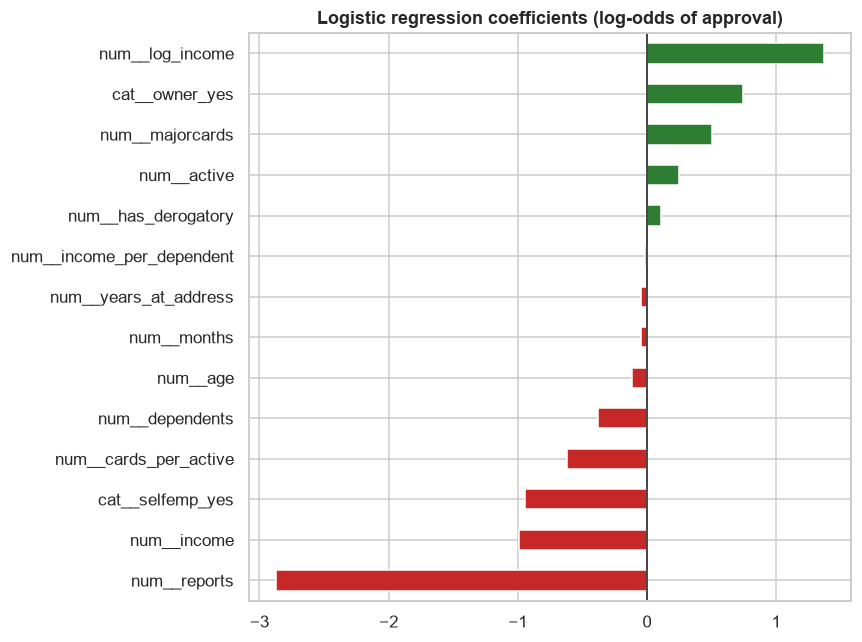

,coef,odds_ratio
num__log_income,1.371,3.938
cat__owner_yes,0.746,2.108
num__majorcards,0.502,1.651
num__active,0.251,1.286
num__has_derogatory,0.106,1.112
num__income_per_dependent,-0.015,0.986
num__months,-0.049,0.952
num__years_at_address,-0.049,0.952
num__age,-0.118,0.889
num__dependents,-0.380,0.684


In [18]:
from sklearn.inspection import permutation_importance

feat_names = final.named_steps["pre"].get_feature_names_out()
clf = final.named_steps["clf"]

if hasattr(clf, "coef_"):
    imp = (pd.Series(clf.coef_[0], index=feat_names).sort_values())
    odds = np.exp(imp).round(3)
    plt.figure(figsize=(8,6))
    imp.plot(kind="barh", color=np.where(imp>0, "#2e7d32", "#c62828"))
    plt.title("Logistic regression coefficients (log-odds of approval)"); plt.axvline(0, c="k", lw=1)
    plt.show()
    display(pd.DataFrame({"coef": imp.round(3), "odds_ratio": odds}).sort_values("coef", ascending=False))
elif hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values()
    plt.figure(figsize=(8,6)); imp.plot(kind="barh", color="#3b6fd4")
    plt.title(f"{best_name} — impurity/gain importance"); plt.show()

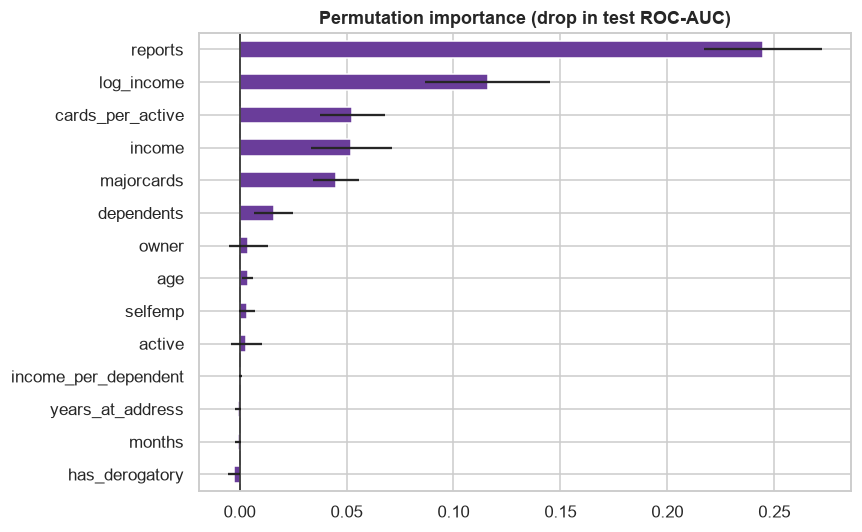

,mean_auc_drop
reports,0.2447
log_income,0.1161
cards_per_active,0.0527
income,0.0522
majorcards,0.0451
dependents,0.0159
owner,0.0040
age,0.0037
selfemp,0.0033
active,0.0030


In [19]:
pi = permutation_importance(final, X_test, y_test, scoring="roc_auc",
                            n_repeats=25, random_state=RANDOM_STATE, n_jobs=-1)
pim = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
plt.figure(figsize=(8,5))
pim.plot(kind="barh", xerr=pd.Series(pi.importances_std, index=X_test.columns).loc[pim.index], color="#6a3d9a")
plt.title("Permutation importance (drop in test ROC-AUC)"); plt.axvline(0, c="k", lw=1)
plt.show()
pim.sort_values(ascending=False).round(4).to_frame("mean_auc_drop")

## 10. Model selection recommendations

### Benchmark summary
Run order in section 6 is by CV ROC-AUC. On leakage-free features the honest ceiling for this dataset is
roughly **0.75–0.85 ROC-AUC** — far below the ~0.99 you get if you leave `share`/`expenditure` in. Any
result near 0.99 on this dataset is a leakage bug, not a good model.

### Recommended models, in order

| Rank | Model | Why | Watch out for |
|---|---|---|---|
| 1 | **Regularized Logistic Regression** (L1/L2) | Credit decisions are regulated (ECOA / Reg B adverse-action notices) — you must state *reasons* for denial. Coefficients give per-applicant reason codes for free, it is stable on n≈1,300, and it is within noise of the tree ensembles here. | Needs scaling + monotone/linear assumption; add splines or binning for nonlinear age/income effects. |
| 2 | **Gradient Boosting / XGBoost** | Best raw ranking power, handles interactions (e.g. reports × active) automatically, robust to unscaled inputs. | Overfits easily at n≈1,300 — keep `max_depth` 2–3, use early stopping; needs SHAP for reason codes. |
| 3 | **Random Forest** | Strong out-of-the-box baseline, low tuning burden, good variance reduction. | Poorly calibrated probabilities — wrap in `CalibratedClassifierCV` before using scores as risk estimates. |
| 4 | **Shallow Decision Tree (depth 3–4)** | A readable scorecard you can hand to a credit committee. | Highest variance; use only as a communication device. |
| 5 | **KNN** | Sanity-check baseline only. | Distance metrics degrade with mixed categorical/numeric data; no interpretability. |

### Practical guidance
- **Metric:** optimize **PR-AUC / recall on the denied class**, not accuracy — a model predicting "approve" for everyone already scores ~78%.
- **Imbalance:** `class_weight="balanced"` (or `scale_pos_weight`) was sufficient here; SMOTE is rarely worth it at this ratio and can distort calibration.
- **Threshold:** section 8 tunes the cutoff explicitly. Set it from the business cost ratio of a bad approval vs. a lost good customer, not at 0.5 by default.
- **Calibration:** if the score feeds pricing or limit assignment, check a reliability curve and apply isotonic/Platt scaling.
- **Fairness:** `age` is a protected attribute under ECOA. Consider excluding it and testing disparate impact across age bands before any deployment.

### Next steps
1. Nested CV for an unbiased estimate of the tuned model's performance.
2. SHAP values for per-decision explanations if a boosted model is chosen.
3. Add spline/binned transforms of `income` and `age` to the logistic model and re-benchmark.
4. Reject-inference: this data only observes outcomes for a filtered population; model the selection process if you plan to score a broader applicant pool.
5. Persist the winning pipeline with `joblib` and wrap it in a scoring function with input validation.
